# What is the most optimal skill to learn for Data Analysts?

### Methodology
>#### 1. Group Skills to determine median salary and likelihood of being in posting
>#### 2. Visualize median salary v/s percent skill demand.
>#### 3. (Optional) Determine if certain technologies are more prevalent

In [1]:
# Importing Libraries

import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data CleanUp
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
# Filter for Data Analyst jobs in the United States

df_DA_US = df[(df['job_title_short'] == "Data Analyst") & (df['job_country'] == "United States")].copy()

# Drop the rows where salary_year_avg is missing

df_DA_US = df_DA_US.dropna(subset = ['salary_year_avg'])

In [3]:
df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_skills = (df_DA_US_exploded.groupby('job_skills')['salary_year_avg']
                .agg(['count', 'median'])
                .sort_values(by = 'count', ascending = False)
)

df_DA_skills

,count,median
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0
...,...,...
couchbase,1,160515.0
chainer,1,100000.0
chef,1,85000.0


In [4]:
df_DA_skills = df_DA_skills.rename({'count' : 'skill_count', 'median':'median_salary'}, axis = 'columns')

df_DA_skills

,skill_count,median_salary
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0
...,...,...
couchbase,1,160515.0
chainer,1,100000.0
chef,1,85000.0


In [5]:
# the total job postings for the dataframe used

DA_job_count = len(df_DA_US)

# the percentage of times the skills appear in the total job postings

df_DA_skills['skills_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

df_DA_skills

,skill_count,median_salary,skills_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
couchbase,1,160515.0,0.022989
chainer,1,100000.0,0.022989
chef,1,85000.0,0.022989


In [6]:
# Limit the size of data to be used for plotting

skills_percent_limit = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skills_percent'] > skills_percent_limit]

df_DA_skills_high_demand

,skill_count,median_salary,skills_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


In [7]:
df_DA_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"[python, r, alteryx, tableau]","{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
180,Data Analyst,Data Analyst III,"Dos Palos, CA",via My ArkLaMiss Jobs,Full-time,False,"California, United States",2023-02-27 13:00:39,False,True,United States,year,90250.0,NaN,California Health & Wellness,"[excel, powerpoint]","{'analyst_tools': ['excel', 'powerpoint']}"
410,Data Analyst,IT Business Lead Data Analyst - VP - Hybrid,"Atlantic Beach, FL",via ComputerJobs.com,Full-time,False,Georgia,2023-01-10 13:59:02,False,False,United States,year,133285.0,NaN,Citi,"[sql, word, excel, visio, powerpoint, sharepoint]","{'analyst_tools': ['word', 'excel', 'visio', '..."
988,Data Analyst,DATA ANALYST (ONSITE),"Springfield, MA",via Indeed,Full-time,False,"New York, United States",2023-11-21 13:00:13,False,False,United States,year,62623.0,NaN,Springfield Public Schools,"[sql, excel, tableau]","{'analyst_tools': ['excel', 'tableau'], 'progr..."
1413,Data Analyst,Junior BI Developer,"Atlanta, GA",via Ai-Jobs.net,Full-time,False,Georgia,2023-10-31 13:57:41,False,True,United States,year,71300.0,NaN,Guidehouse,"[sql, excel, power bi]","{'analyst_tools': ['excel', 'power bi'], 'prog..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782637,Data Analyst,Data Integration Analyst,"Germantown, WI",via ZipRecruiter,Full-time,False,"Illinois, United States",2023-01-20 06:18:43,True,False,United States,year,70000.0,NaN,Virtual Benefits Administrator,"[vba, sql, sql server]","{'databases': ['sql server'], 'programming': [..."
782798,Data Analyst,Reference Data Analyst,"New York, NY",via Ai-Jobs.net,Full-time,False,"New York, United States",2023-04-21 05:59:51,True,False,United States,year,111175.0,NaN,DRW,[terminal],{'other': ['terminal']}
783588,Data Analyst,Data Analytics Manager,"Chicago, IL",via Ladders,Full-time,False,"Illinois, United States",2023-01-09 06:01:18,False,False,United States,year,125000.0,NaN,"United Air Lines, Inc","[sql, r, python, hadoop, excel]","{'analyst_tools': ['excel'], 'libraries': ['ha..."
783866,Data Analyst,Lead Credit Bureau Data Analyst,"Des Plaines, IL",via Ladders,Full-time,False,"Illinois, United States",2023-06-02 06:02:06,False,True,United States,year,115000.0,NaN,Discover Financial Services,[unix],{'os': ['unix']}


In [8]:
df['job_title_short'].unique()

array(['Senior Data Engineer', 'Data Analyst', 'Data Engineer',
       'Business Analyst', 'Data Scientist', 'Machine Learning Engineer',
       'Senior Data Analyst', 'Cloud Engineer', 'Senior Data Scientist',
       'Software Engineer'], dtype=object)

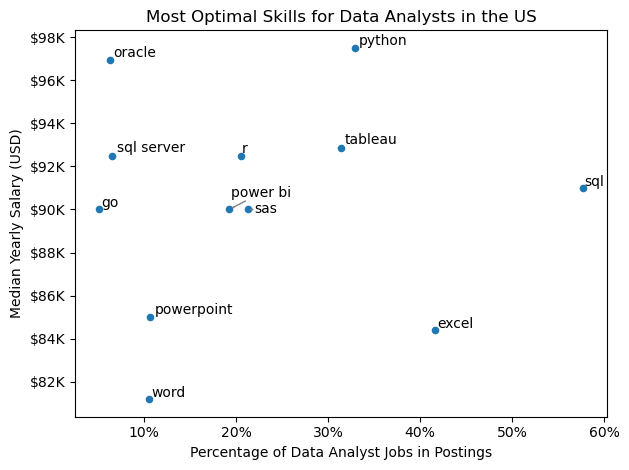

In [12]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind = 'scatter', x = 'skills_percent', y = 'median_salary')

text = []

for i, txt in enumerate(df_DA_skills_high_demand.index):
    text.append(plt.text(df_DA_skills_high_demand['skills_percent'].iloc[i], 
                            df_DA_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(text, arrowprops = dict(arrowstyle = '->', color = 'grey', lw = 1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

from matplotlib.ticker import PercentFormatter

ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))

# Set axis labels, legend and title
plt.xlabel('Percentage of Data Analyst Jobs in Postings')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Most Optimal Skills for Data Analysts in the US')

# Adjust layout
plt.tight_layout()
plt.show()


In [18]:
# retrieve the column of data that holds the classification of the skills
df_technology = df['job_type_skills'].copy()

df_technology = df_technology.drop_duplicates()

df_technology = df_technology.dropna()

df_technology[1]

"{'analyst_tools': ['power bi', 'tableau'], 'programming': ['r', 'python', 'sql', 'nosql']}"

In [24]:
# combine all dictionaries into one

technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row) # convert string to dictionary, remove quotations. initially dictionary as string

    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value
        
# remove the duplicates by converting the list values to set then back to list

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))


In [25]:
technology_dict

{'analyst_tools': ['power bi',
  'excel',
  'sheets',
  'powerbi',
  'word',
  'sharepoint',
  'ms access',
  'esquisse',
  'qlik',
  'microstrategy',
  'sas',
  'ssrs',
  'alteryx',
  'spreadsheet',
  'tableau',
  'nuix',
  'msaccess',
  'cognos',
  'dax',
  'ssis',
  'outlook',
  'visio',
  'looker',
  'splunk',
  'datarobot',
  'powerpoint',
  'sap',
  'spss'],
 'programming': ['clojure',
  'css',
  'matlab',
  'visual basic',
  'sass',
  'assembly',
  'php',
  'python',
  'vba',
  'kotlin',
  'golang',
  'ruby',
  'bash',
  'c',
  'go',
  'javascript',
  'sas',
  'lua',
  'cobol',
  'julia',
  'groovy',
  'sql',
  'solidity',
  'nosql',
  'f#',
  'apl',
  'powershell',
  'no-sql',
  'c#',
  'lisp',
  'haskell',
  't-sql',
  'html',
  'mongodb',
  'rust',
  'dart',
  'crystal',
  'pascal',
  'c++',
  'shell',
  'erlang',
  'scala',
  'visualbasic',
  'r',
  'typescript',
  'perl',
  'ocaml',
  'java',
  'objective-c',
  'swift',
  'delphi',
  'elixir',
  'mongo',
  'vb.net',
  'fort

In [28]:
# convert the dictionary to a dataframe and assign columns

df_technology = pd.DataFrame(list(technology_dict.items()), columns = ['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,power bi
0,analyst_tools,excel
0,analyst_tools,sheets
0,analyst_tools,powerbi
0,analyst_tools,word
...,...,...
9,sync,mattermost
9,sync,rocketchat
9,sync,google chat
9,sync,ringcentral


In [29]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on = 'job_skills', right_on = 'skills')

df_plot

,skill_count,median_salary,skills_percent,technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,926,90000.00,21.287356,analyst_tools,sas
5,926,90000.00,21.287356,programming,sas
6,893,92500.00,20.528736,programming,r
7,838,90000.00,19.264368,analyst_tools,power bi
8,462,85000.00,10.620690,analyst_tools,powerpoint
9,461,81194.75,10.597701,analyst_tools,word


4 [-0.1629329   0.29044429]
5 [-0.91621863 -0.98959571]


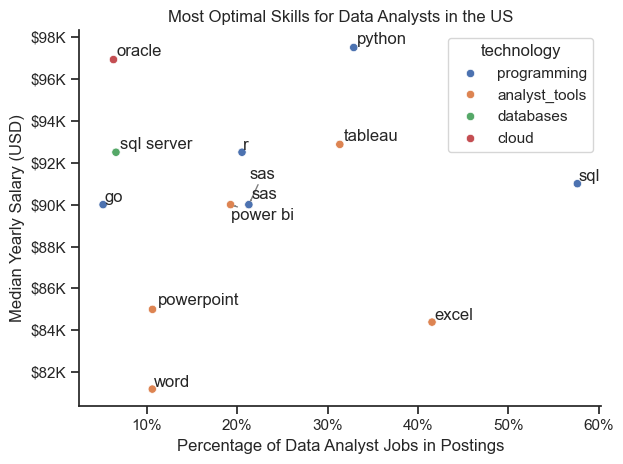

In [35]:
from adjustText import adjust_text

sns.scatterplot(data = df_plot, 
                x = 'skills_percent', 
                y = 'median_salary',
                hue = 'technology')

sns.despine()
sns.set_theme(style = 'ticks')

text = []

for i, txt in enumerate(df_plot.skills):
    text.append(plt.text(df_plot['skills_percent'].iloc[i], 
                            df_plot['median_salary'].iloc[i], txt))

adjust_text(text, arrowprops = dict(arrowstyle = '->', color = 'grey', lw = 1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

from matplotlib.ticker import PercentFormatter

ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))

# Set axis labels, legend and title
plt.xlabel('Percentage of Data Analyst Jobs in Postings')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Most Optimal Skills for Data Analysts in the US')

# Adjust layout
plt.tight_layout()
plt.show()